# The Human Cost of Civilian Targeting
## 02 — Analysis by research question

**Central question:** *How has violence against civilians changed globally between 2021 and 2025, and where has its human cost been most severe?*

The analysis follows the four research questions presented in the final slides:

1. **Which regions record the highest number of civilian-targeting events?**
2. **How does the human cost of civilian-targeting vary across regions?**
3. **Which forms drive fatalities in the most affected regions?**
4. **Which countries show the greatest need for attention from a civilian-protection perspective?**


### Analytical scope

The analysis uses every available event from **1 January 2021 to 25 August 2025**. The years 2021–2024 are complete; 2025 is partial and is marked with an asterisk wherever annual values are shown.

`fatalities` refers to **reported fatalities in civilian-targeting events**. The Relative Attention Index is a comparative indicator built from ACLED event frequency and lethality; it is not an official humanitarian-needs index and should not be interpreted as individual risk.


## 1. Setup and validation


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

NAVY = "#183B56"
CORAL = "#E76F51"
TEAL = "#2A9D8F"
GOLD = "#E9C46A"


In [2]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_DIR = next(
    (path for path in [CURRENT_DIR, *CURRENT_DIR.parents]
     if (path / "requirements.txt").exists() and (path / "data").is_dir()),
    CURRENT_DIR,
)
DATA_PATH = PROJECT_DIR / "data" / "processed" / "acled_civilian_targeting_2021_2025.parquet"
TABLE_DIR = PROJECT_DIR / "data" / "analysis"
FIGURE_DIR = PROJECT_DIR / "outputs" / "eda_figures"

# These filenames are retained because the existing Tableau workbook already uses them.
TABLEAU_COUNTRY_PATH = PROJECT_DIR / "RQ5_tableau_country_level.csv"
TABLEAU_EVENT_PATH = PROJECT_DIR / "RQ5_tableau_event_level.csv"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01_acled_data_cleaning.ipynb first.")

analysis_df = pd.read_parquet(DATA_PATH)
analysis_end_date = analysis_df["event_date"].max()
partial_year = int(analysis_end_date.year)

def save_figure(fig, filename):
    fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight", facecolor="white")
    fig.savefig(FIGURE_DIR / f"{filename}.svg", bbox_inches="tight", facecolor="white")

assert not analysis_df.empty
assert analysis_df["event_id_cnty"].is_unique
assert analysis_df["fatalities"].notna().all()
assert analysis_df["fatalities"].ge(0).all()
assert analysis_df["event_date"].min() == pd.Timestamp("2021-01-01")
assert analysis_end_date == pd.Timestamp("2025-08-25")
assert analysis_df["year"].isin(range(2021, 2026)).all()

print(f"Events: {len(analysis_df):,}")
print(f"Countries/territories: {analysis_df['country'].nunique():,}")
print(f"Period: {analysis_df['event_date'].min():%d/%m/%Y}–{analysis_end_date:%d/%m/%Y}")
print("✓ Dataset validated: 2021–2024 full years; 2025 partial through 25 August.")


Events: 251,579
Countries/territories: 190
Period: 01/01/2021–25/08/2025
✓ Dataset validated: 2021–2024 full years; 2025 partial through 25 August.


## 2. RQ1 — Which regions record the highest number of civilian-targeting events?

The heatmap reports absolute event counts by ACLED region and year. It measures the concentration of recorded events, not individual risk. The `2025*` column is partial and must be read separately from the complete years.


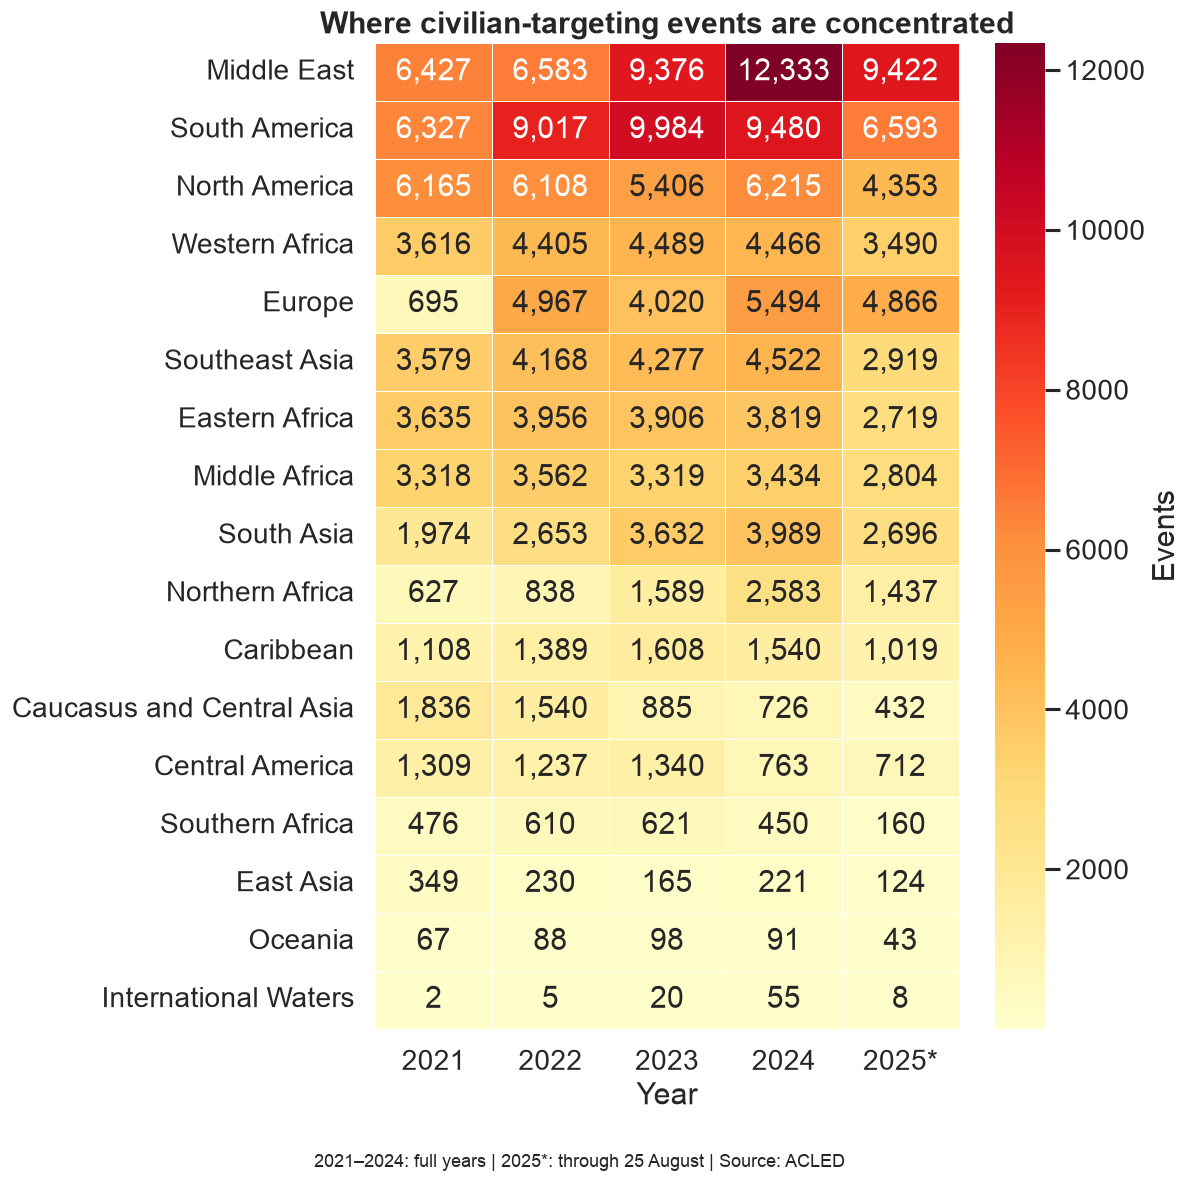

In [3]:
region_year = (
    analysis_df.groupby(["region", "year"], observed=True)
    .agg(
        events=("event_id_cnty", "size"),
        fatalities=("fatalities", "sum"),
    )
    .reset_index()
)
region_total = (
    region_year.groupby("region", observed=True)[["events", "fatalities"]]
    .sum()
    .sort_values("events", ascending=False)
)
region_year.to_csv(TABLE_DIR / "rq1_region_year.csv", index=False)
region_total.to_csv(TABLE_DIR / "rq1_region_totals.csv")

event_heatmap = (
    region_year.pivot(index="region", columns="year", values="events")
    .reindex(region_total.index)
    .fillna(0)
    .astype(float)
)
event_heatmap.columns = [
    str(year) if year != partial_year else f"{year}*"
    for year in event_heatmap.columns
]

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    event_heatmap,
    cmap="YlOrRd",
    annot=True,
    fmt=",.0f",
    linewidths=0.6,
    cbar_kws={"label": "Events"},
    ax=ax,
)
ax.set(title="Where civilian-targeting events are concentrated", xlabel="Year", ylabel="")
fig.text(
    0.5, 0.01,
    "2021–2024: full years | 2025*: through 25 August | Source: ACLED",
    ha="center", fontsize=11,
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
save_figure(fig, "rq1_region_events_heatmap")
plt.show()


### Results

Civilian-targeting is unevenly distributed across regions. The **Middle East** records the highest total with **44,141 events**, followed by **South America** with **41,401**. Both remain among the regions with the highest event counts across 2021–2025 despite year-to-year variation. The Middle East also reaches the largest annual value, **12,333 events in 2024**; its **9,422 events in 2025** cover only the period through 25 August.

These counts describe frequency, not human loss. The next question therefore compares the regional ranking by events with the ranking by reported fatalities.


## 3. RQ2 — How does the human cost of civilian-targeting vary across regions?

The two rankings use the same four regions and stable colors. The first shows event frequency; the second shows reported fatalities across the available 2021–2025 period.


In [4]:
region_summary = (
    analysis_df.groupby("region", observed=True)
    .agg(
        events=("event_id_cnty", "size"),
        fatalities=("fatalities", "sum"),
    )
    .reset_index()
)

REGION_COLORS = {
    "Middle East": NAVY,
    "South America": CORAL,
    "North America": TEAL,
    "Western Africa": GOLD,
}
HIGHLIGHT_REGIONS = {"Middle East", "Western Africa"}

def prepare_region_ranking(metric):
    ranking = region_summary.nlargest(4, metric).copy()
    ranking["bar_color"] = ranking["region"].map(REGION_COLORS)
    return ranking.sort_values(metric)

top_region_events = prepare_region_ranking("events")
top_region_fatalities = prepare_region_ranking("fatalities")
region_summary.to_csv(TABLE_DIR / "rq2_region_events_and_fatalities.csv", index=False)


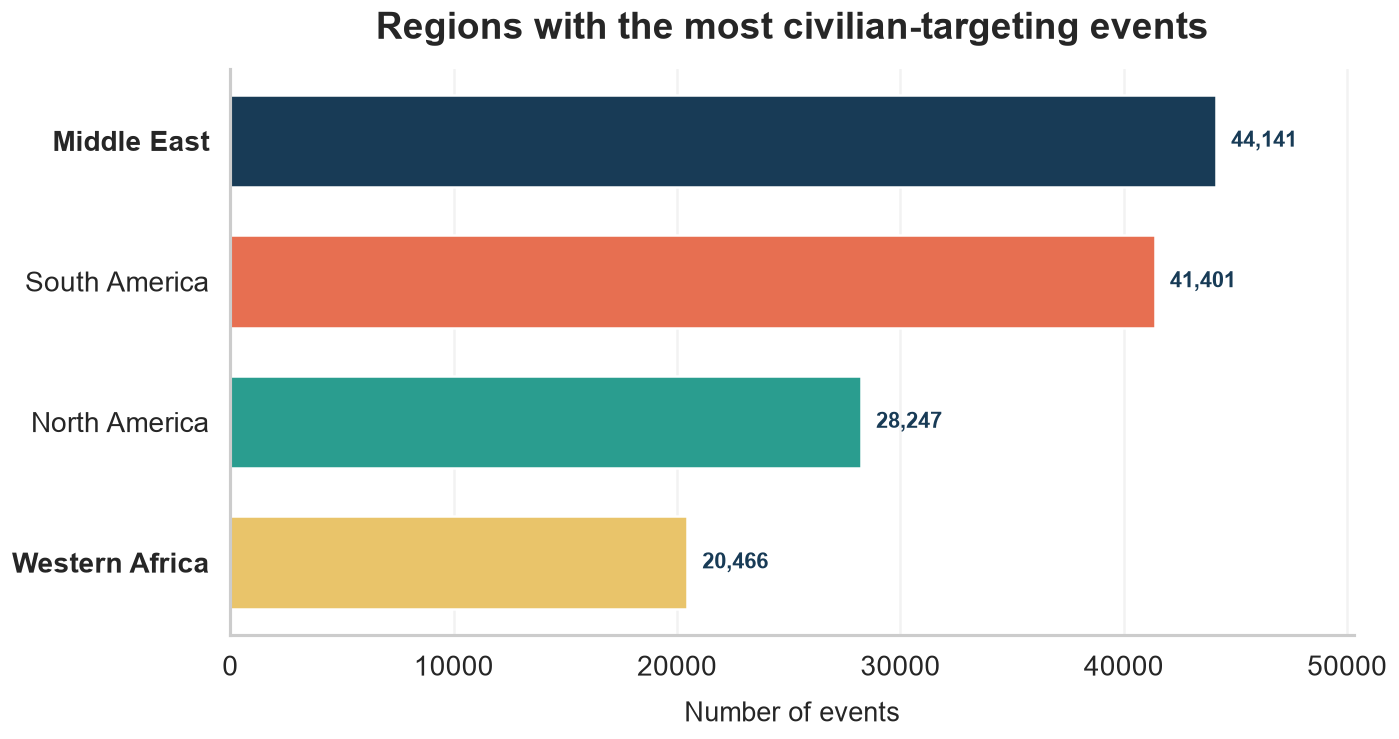

In [5]:
fig, ax = plt.subplots(figsize=(12, 6.5))
bars = ax.barh(
    top_region_events["region"],
    top_region_events["events"],
    color=top_region_events["bar_color"],
    height=0.66,
)
for bar, value in zip(bars, top_region_events["events"]):
    ax.text(
        value + top_region_events["events"].max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center", fontsize=13, fontweight="bold", color=NAVY,
    )
ax.set_xlim(0, top_region_events["events"].max() * 1.14)
ax.set_title("Regions with the most civilian-targeting events", fontsize=22, pad=18)
ax.set_xlabel("Number of events", fontsize=16, labelpad=12)
ax.set_ylabel("")
for label in ax.get_yticklabels():
    if label.get_text() in HIGHLIGHT_REGIONS:
        label.set_fontweight("bold")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "rq2_top_regions_events")
plt.show()


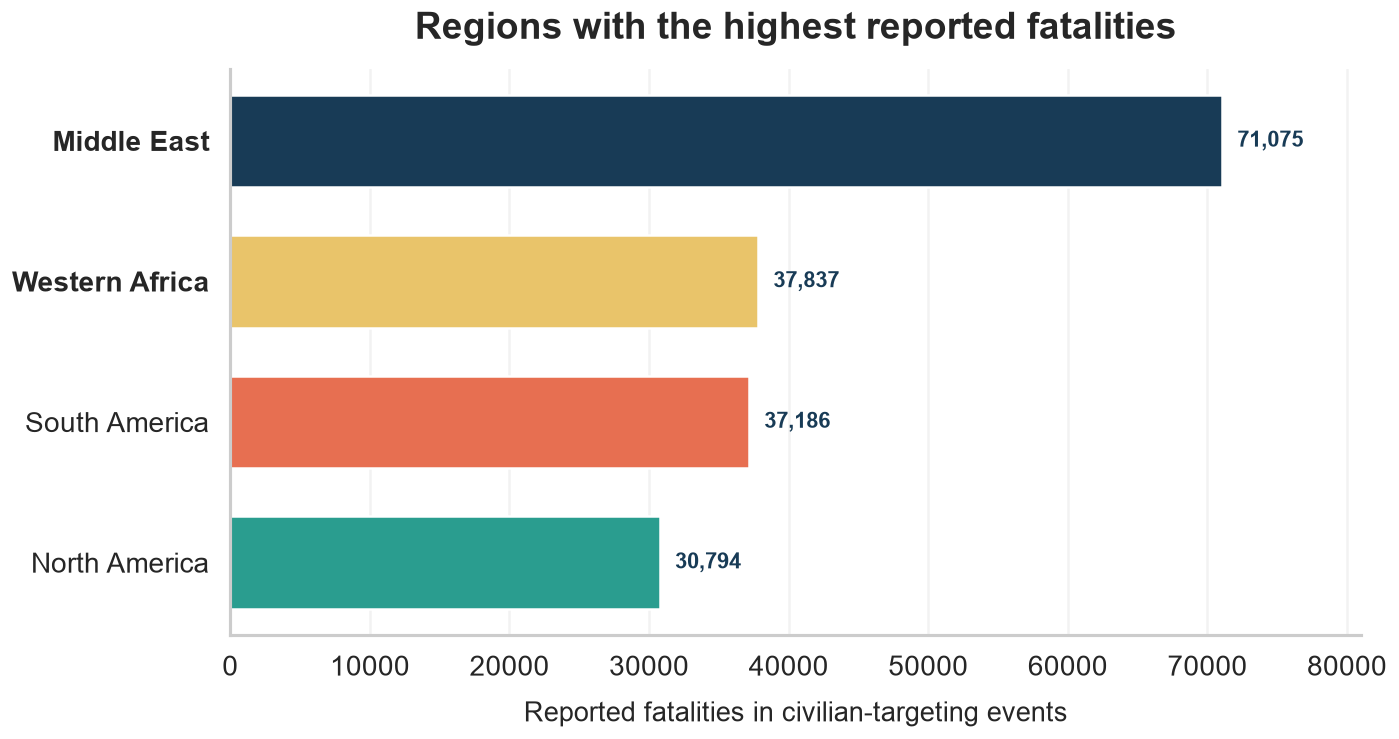

In [6]:
fig, ax = plt.subplots(figsize=(12, 6.5))
bars = ax.barh(
    top_region_fatalities["region"],
    top_region_fatalities["fatalities"],
    color=top_region_fatalities["bar_color"],
    height=0.66,
)
for bar, value in zip(bars, top_region_fatalities["fatalities"]):
    ax.text(
        value + top_region_fatalities["fatalities"].max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center", fontsize=13, fontweight="bold", color=NAVY,
    )
ax.set_xlim(0, top_region_fatalities["fatalities"].max() * 1.14)
ax.set_title("Regions with the highest reported fatalities", fontsize=22, pad=18)
ax.set_xlabel("Reported fatalities in civilian-targeting events", fontsize=16, labelpad=12)
ax.set_ylabel("")
for label in ax.get_yticklabels():
    if label.get_text() in HIGHLIGHT_REGIONS:
        label.set_fontweight("bold")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "rq2_top_regions_fatalities")
plt.show()


### Results

Frequency explains only part of the human burden. The **Middle East** ranks first for both events (**44,141**) and reported fatalities (**71,075**). **Western Africa** rises from fourth place by frequency (**20,466 events**) to second by human cost (**37,837 fatalities**), narrowly ahead of **South America** (**37,186**) and despite far fewer events than South America or North America.

The change in ranking shows that the human cost depends not only on how often violence occurs, but also on the form it takes.


## 4. RQ3 — Which forms drive fatalities in the most affected regions?

The comparison focuses on the two regions with the highest total reported fatalities: the **Middle East** and **Western Africa**. The displayed categories are the union of each region's three highest-fatality `sub_event_type` values. `Attack` follows the ACLED taxonomy and refers here to a direct attack against civilians.


In [7]:
region_fatality_totals = (
    analysis_df.groupby("region", observed=True)["fatalities"]
    .sum()
    .sort_values(ascending=False)
)
highest_fatality_regions = region_fatality_totals.head(2).index.tolist()
assert highest_fatality_regions == ["Middle East", "Western Africa"]

region_subtypes = (
    analysis_df.loc[analysis_df["region"].isin(highest_fatality_regions)]
    .groupby(["sub_event_type", "region"], observed=True)["fatalities"]
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=highest_fatality_regions, fill_value=0)
)
region_subtypes["combined_fatalities"] = region_subtypes[highest_fatality_regions].sum(axis=1)

top_subtype_names = set()
for region in highest_fatality_regions:
    top_subtype_names.update(region_subtypes.nlargest(3, region).index)

top_region_subtypes = (
    region_subtypes.loc[list(top_subtype_names)]
    .sort_values("combined_fatalities")
)
top_region_subtypes.to_csv(TABLE_DIR / "rq3_forms_by_highest_fatality_regions.csv")
display(top_region_subtypes.sort_values("combined_fatalities", ascending=False))


region,Middle East,Western Africa,combined_fatalities
sub_event_type,,,
Air/drone strike,47916,1415,49331
Attack,13572,34132,47704
Shelling/artillery/missile attack,5856,46,5902
Remote explosive/landmine/IED,3244,1074,4318


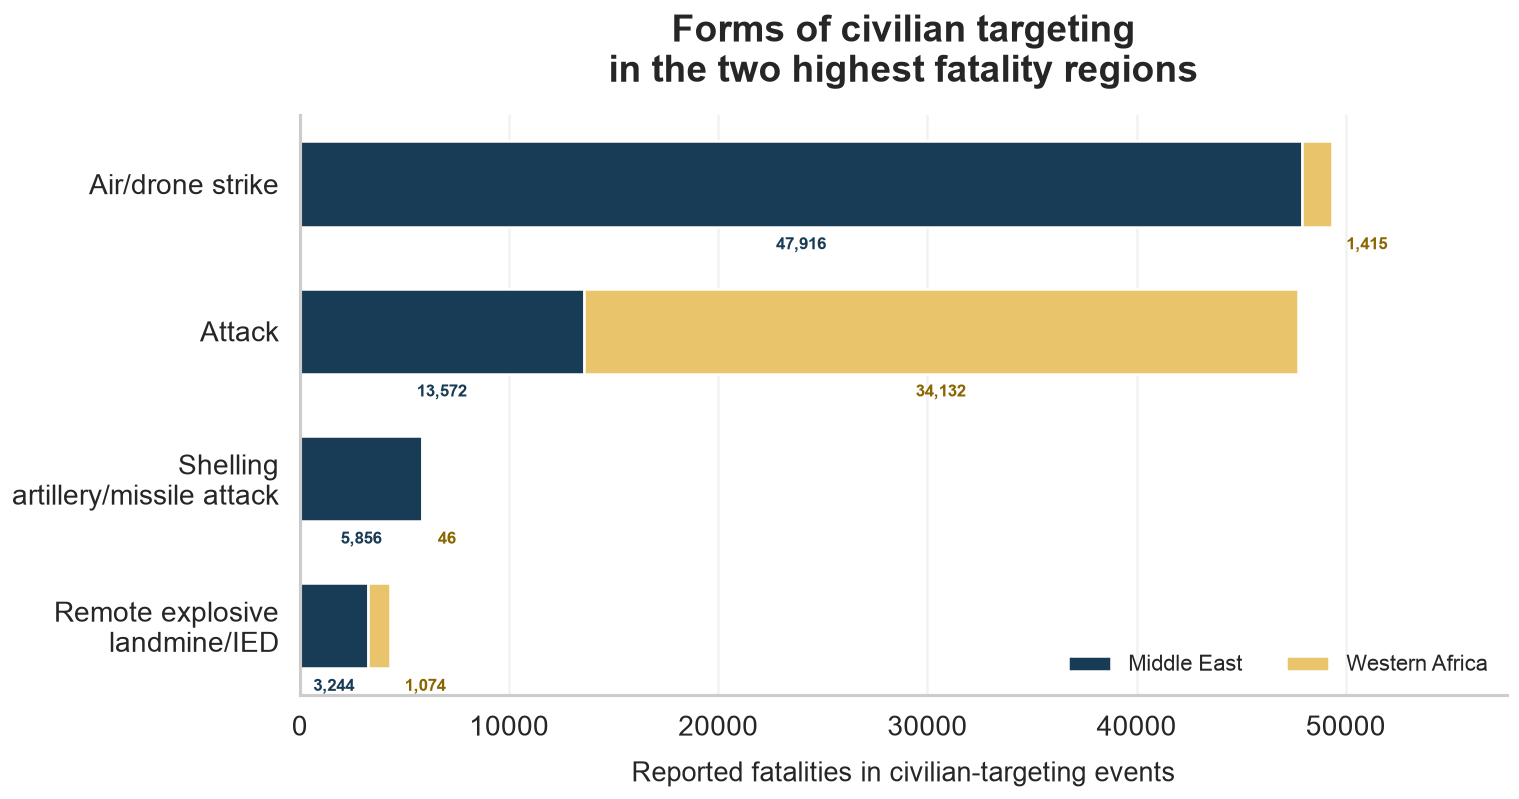

In [8]:
middle_east_values = top_region_subtypes["Middle East"]
western_africa_values = top_region_subtypes["Western Africa"]
combined_values = top_region_subtypes["combined_fatalities"]
wrapped_labels = {
    "Shelling/artillery/missile attack": "Shelling\nartillery/missile attack",
    "Remote explosive/landmine/IED": "Remote explosive\nlandmine/IED",
}
axis_labels = [wrapped_labels.get(name, name) for name in top_region_subtypes.index]

fig, ax = plt.subplots(figsize=(13, 7))
middle_east_bars = ax.barh(
    axis_labels, middle_east_values, color=NAVY, height=0.58, label="Middle East",
)
western_africa_bars = ax.barh(
    axis_labels, western_africa_values, left=middle_east_values,
    color=GOLD, height=0.58, label="Western Africa",
)

axis_maximum = combined_values.max() * 1.17
for middle_bar, western_bar, middle_value, western_value, combined_value in zip(
    middle_east_bars,
    western_africa_bars,
    middle_east_values,
    western_africa_values,
    combined_values,
):
    label_y = middle_bar.get_y() - 0.07
    ax.text(
        middle_value / 2, label_y, f"{middle_value:,.0f}",
        ha="center", va="top", fontsize=10, fontweight="bold", color=NAVY,
    )
    western_label_x = (
        middle_value + western_value / 2
        if western_value >= axis_maximum * 0.07
        else combined_value + axis_maximum * 0.012
    )
    ax.text(
        western_label_x, label_y, f"{western_value:,.0f}",
        ha="center" if western_value >= axis_maximum * 0.07 else "left",
        va="top", fontsize=10, fontweight="bold", color="#8A6500",
    )

ax.set_xlim(0, axis_maximum)
ax.set_title(
    "Forms of civilian targeting\nin the two highest fatality regions",
    fontsize=22, pad=20,
)
ax.set_xlabel("Reported fatalities in civilian-targeting events", fontsize=16, labelpad=12)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", frameon=False, fontsize=13, ncol=2)
fig.tight_layout()
save_figure(fig, "rq3_forms_highest_fatality_regions")
plt.show()


### Results

The forms associated with the highest reported fatalities differ sharply across the two regions. In the **Middle East**, `Air/drone strike` dominates with **47,916 reported fatalities**, compared with **13,572** from `Attack`. In **Western Africa**, `Attack` is the main source of reported human loss with **34,132 fatalities**, while `Air/drone strike` accounts for **1,415**.

`Shelling/artillery/missile attack` records **5,856** fatalities in the Middle East and **46** in Western Africa. `Remote explosive/landmine/IED`, included because it is among Western Africa's top three, records **3,244** and **1,074**, respectively. These are totals, so they reflect both the number and the severity of recorded events.


## 5. RQ4 — Which countries show the greatest need for attention from a civilian-protection perspective?

 **Relative Attention Index used in Tableau**. It combines:

- **Frequency:** total civilian-targeting events per country.
- **Lethality:** reported fatalities per event per country.

Each measure is converted to a 0–100 percentile using Tableau's rank-percentile logic. The two dimensions receive equal weight through their geometric mean:

$$RAI = \sqrt{P_{events} \times P_{fatalities/event}}$$

The geometric mean rewards countries that are high on both dimensions and prevents one dimension from fully compensating for a very low value on the other. The four descriptive severity categories use the 75th percentile as the threshold for “high”. The index is relative to the countries in this dataset and is not a comprehensive humanitarian-needs measure.


In [9]:
country_attention = (
    analysis_df.groupby("country", observed=True)
    .agg(
        total_events=("event_id_cnty", "size"),
        total_fatalities=("fatalities", "sum"),
        fatalities_per_event=("fatalities", "mean"),
        centroid_latitude=("latitude", "mean"),
        centroid_longitude=("longitude", "mean"),
    )
    .reset_index()
)

def tableau_rank_percentile(series):
    # Replicate Tableau RANK_PERCENTILE with average ranks for ties.
    if len(series) == 1:
        return pd.Series(100.0, index=series.index)
    ascending_rank = series.rank(method="average", ascending=True)
    return 100 * (ascending_rank - 1) / (len(series) - 1)

country_attention["events_rank"] = (
    country_attention["total_events"].rank(method="first", ascending=False).astype(int)
)
country_attention["fatalities_rank"] = (
    country_attention["total_fatalities"].rank(method="first", ascending=False).astype(int)
)
country_attention["lethality_rank"] = (
    country_attention["fatalities_per_event"].rank(method="first", ascending=False).astype(int)
)

country_attention["event_percentile_raw"] = tableau_rank_percentile(country_attention["total_events"])
country_attention["lethality_percentile_raw"] = tableau_rank_percentile(
    country_attention["fatalities_per_event"]
)
country_attention["fatalities_percentile_raw"] = tableau_rank_percentile(
    country_attention["total_fatalities"]
)
country_attention["attention_index_raw"] = np.sqrt(
    country_attention["event_percentile_raw"]
    * country_attention["lethality_percentile_raw"]
)

country_attention["event_percentile"] = country_attention["event_percentile_raw"].round(1)
country_attention["lethality_percentile"] = country_attention["lethality_percentile_raw"].round(1)
country_attention["fatalities_percentile"] = country_attention["fatalities_percentile_raw"].round(1)
country_attention["attention_index"] = country_attention["attention_index_raw"].round(1)
country_attention["attention_rank"] = (
    country_attention["attention_index_raw"].rank(method="first", ascending=False).astype(int)
)

high_frequency = country_attention["event_percentile_raw"].ge(75)
high_lethality = country_attention["lethality_percentile_raw"].ge(75)
country_attention["severity_category"] = np.select(
    [
        high_frequency & high_lethality,
        high_frequency & ~high_lethality,
        ~high_frequency & high_lethality,
    ],
    [
        "High frequency + high lethality",
        "High frequency + lower lethality",
        "Lower frequency + high lethality",
    ],
    default="Lower frequency + lower lethality",
)

country_attention = country_attention.sort_values(
    ["attention_rank", "country"]
).reset_index(drop=True)

country_export_columns = [
    "country", "total_events", "total_fatalities", "fatalities_per_event",
    "events_rank", "fatalities_rank", "lethality_rank",
    "event_percentile", "lethality_percentile", "fatalities_percentile",
    "attention_index", "attention_rank", "severity_category",
    "centroid_latitude", "centroid_longitude",
]
country_export = country_attention[country_export_columns].copy()
country_export["fatalities_per_event"] = country_export["fatalities_per_event"].round(4)
country_export["centroid_latitude"] = country_export["centroid_latitude"].round(5)
country_export["centroid_longitude"] = country_export["centroid_longitude"].round(5)
country_export.to_csv(TABLEAU_COUNTRY_PATH, index=False, encoding="utf-8-sig")

event_attention = (
    analysis_df.rename(columns={"event_id_cnty": "event_id"})
    .merge(
        country_attention[[
            "country", "severity_category", "attention_index", "attention_rank",
        ]],
        on="country",
        how="left",
        validate="many_to_one",
    )
)
event_export_columns = [
    "country", "event_id", "fatalities", "latitude", "longitude", "year",
    "event_date", "civilian_targeting", "event_type", "sub_event_type",
    "severity_category", "attention_index", "attention_rank",
]
event_attention[event_export_columns].to_csv(
    TABLEAU_EVENT_PATH, index=False, encoding="utf-8-sig", date_format="%Y-%m-%d"
)

display(country_attention[country_export_columns].head(15))
print(f"Tableau country file: {TABLEAU_COUNTRY_PATH}")
print(f"Tableau event file: {TABLEAU_EVENT_PATH}")


,country,total_events,total_fatalities,fatalities_per_event,events_rank,fatalities_rank,lethality_rank,event_percentile,lethality_percentile,fatalities_percentile,attention_index,attention_rank,severity_category,centroid_latitude,centroid_longitude
0,Palestine,19903,50602,2.54,3,1,4,98.90,98.40,100.00,98.70,1,High frequency + high lethality,31.70,34.78
1,Democratic Republic of Congo,7908,17741,2.24,8,5,8,96.30,96.30,97.90,96.30,2,High frequency + high lethality,-0.55,28.85
2,Sudan,6295,15702,2.49,13,7,5,93.70,97.90,96.80,95.70,3,High frequency + high lethality,13.92,29.62
3,Nigeria,11166,18734,1.68,7,4,15,96.80,92.60,98.40,94.70,4,High frequency + high lethality,9.29,7.34
4,Ethiopia,2690,10950,4.07,22,9,2,88.90,99.50,95.80,94.00,5,High frequency + high lethality,9.96,37.99
5,Mali,3208,7334,2.29,18,13,7,91.00,96.80,93.70,93.90,6,High frequency + high lethality,15.16,-2.94
6,Burkina Faso,2645,7653,2.89,24,11,3,87.80,98.90,94.70,93.20,7,High frequency + high lethality,12.85,-1.00
7,Mexico,27553,30489,1.11,1,2,29,100.00,85.20,99.50,92.30,8,High frequency + high lethality,21.90,-101.59
8,South Sudan,4262,6783,1.59,16,15,18,92.10,91.00,92.60,91.50,9,High frequency + high lethality,6.84,30.85
9,Haiti,2939,4831,1.64,20,16,16,89.90,92.10,92.10,91.00,10,High frequency + high lethality,18.67,-72.40


Tableau country file: /Users/nicole/Desktop/projects/datavis/RQ5_tableau_country_level.csv
Tableau event file: /Users/nicole/Desktop/projects/datavis/RQ5_tableau_event_level.csv


In [10]:
top_two = country_attention.nsmallest(2, "attention_rank")

assert len(country_attention) == analysis_df["country"].nunique()
assert country_attention["attention_rank"].is_unique
assert country_attention["attention_index"].between(0, 100).all()
assert top_two["country"].tolist() == ["Palestine", "Democratic Republic of Congo"]
assert top_two["total_events"].tolist() == [19_903, 7_908]
assert top_two["total_fatalities"].tolist() == [50_602, 17_741]
assert top_two["attention_index"].tolist() == [98.7, 96.3]

display(top_two[country_export_columns])
print("✓ Relative Attention Index matches the Tableau results used in the slides.")


,country,total_events,total_fatalities,fatalities_per_event,events_rank,fatalities_rank,lethality_rank,event_percentile,lethality_percentile,fatalities_percentile,attention_index,attention_rank,severity_category,centroid_latitude,centroid_longitude
0,Palestine,19903,50602,2.54,3,1,4,98.90,98.40,100.00,98.70,1,High frequency + high lethality,31.70,34.78
1,Democratic Republic of Congo,7908,17741,2.24,8,5,8,96.30,96.30,97.90,96.30,2,High frequency + high lethality,-0.55,28.85


✓ Relative Attention Index matches the Tableau results used in the slides.


### Results

**Palestine** ranks first with a Relative Attention Index of **98.7**. It combines **19,903 events** with **50,602 reported fatalities**, or **2.5424 fatalities per event**. In the Tableau event map, air/drone strikes are concentrated mainly in Gaza, while attacks are more widespread across the West Bank.

The **Democratic Republic of Congo** ranks second with an index of **96.3**, based on **7,908 events** and **17,741 reported fatalities**, or **2.2434 fatalities per event**. Its events are concentrated mainly in the eastern part of the country, especially near border areas; attacks and abductions/forced disappearances are strongly represented there.

These results identify the strongest overlap of recorded frequency and lethality within this dataset. They do not include displacement, access to aid, institutional capacity, underreporting, or other dimensions required for a complete assessment of civilian-protection needs.


### Reporting rules

1. Use **reported fatalities in civilian-targeting events**, not automatically “civilian deaths”.
2. State **2021–2024 full years; 2025 partial through 25 August**.
3. Describe the Relative Attention Index as the geometric mean of the event-frequency and lethality percentiles.
4. Present the index as a relative ACLED-based comparison, not an official needs or individual-risk measure.
5. Avoid causal claims: the project describes concentration, recorded human loss, and differences in the forms of violence.
